# Voxel-wise Permutation Testing demo

## Data simulation 

We simulate a null fMRI dataset with no true activation.  
For each subject ( i = 1, ... , n ), we generate a 2-D image Yi(x, y)  of size S*S (Currently S = 64) voxels.

### 1. Noise generation

Each voxel is drawn independently from a uniform distribution:

$$
Y_i(x, y) \sim \mathrm{Uniform}(-1, 1).
$$


### 2. Smoothing

To introduce spatial correlation, each image is convolved with a 
Gaussian smoothing kernel.

### 3. Final dataset

The simulated null dataset is:

$$
\{\, Y_i^{\text{smooth}}(x,y) \;:\; i=1,\dots,n \,\}
$$

with no true activation anywhere in the image.

# Models Used:

# One sample model (no labels)

Each voxel has observations:

$$
y = (y_1, y_2, \ldots, y_n)^\top.
$$

The design matrix is

$$
X =
\begin{bmatrix}
1 \\
1 \\
\vdots \\
1
\end{bmatrix}
\quad (n \times 1).
$$

The model is:

$$
y = X\beta + \varepsilon,
$$

where

- $\beta$ is the mean activation,  
- $\varepsilon \sim \mathcal{N}(0, \sigma^2 I)$.


The null hypothesis is

$$
H_0: \beta(v) = 0,
$$

that is, the mean signal at voxel \(v\) is zero.


The alternative hypothesis is

$$
H_1: \beta(v) \neq 0.
$$



### Contrast

$$
L = [1].
$$

### t statistic

$$
t(v) = \frac{L^\top \hat{\beta}(v)}{\sqrt{\hat{\sigma}^2(v)\, L^\top (X^\top X)^{-1} L}}.
$$


---

# Two sample model (with labels)

Let the subjects be in two equal groups.

The design matrix is

$$
X =
\begin{bmatrix}
1 & 0 \\
\vdots & \vdots \\
1 & 0 \\
0 & 1 \\
\vdots & \vdots \\
0 & 1
\end{bmatrix}
\quad (n \times 2).
$$

The model:

$$
y = X\beta + \varepsilon,
$$

with

$$
\beta =
\begin{bmatrix}
\mu_1 \\
\mu_2
\end{bmatrix},
\qquad
\varepsilon \sim \mathcal{N}(0, \sigma^2 I).
$$

### Contrast

$$
L = [\,1,\ -1\,].
$$

Tests:

$$
H_0:\ \mu_1 - \mu_2 = 0.
$$

### t statistic

$$
t(v) = 
\frac{L^\top \hat{\beta}(v)}
     {\sqrt{\hat{\sigma}^2(v)\, L^\top (X^\top X)^{-1} L}}.
$$


---

## Permutation Methods

### One sample (sign flipping)

Under the null:

$$
y_i^{new} = s_i\, y_i, \qquad s_i \in \{-1, +1\}.
$$

Each subject's sign is flipped independently with a 50:50 chance.


### Two sample (label shuffling)

Under the null, labels are exchangeable:

$$
X^{new} = \text{random permutation of rows of } X.
$$

This keeps the same number of subjects per group.


### Distribution of max T value

For each permutation

$$
m_p = \max_v \bigl|t_p(v)\bigr|.
$$


### Permutation threshold

$$
t_{\text{thr}} = \text{quantile}_{1-\alpha}(m_1,\dots,m_P).
$$


### Corrected significance map

$$
\text{sig}(v) = \mathbf{1}\{\,|t_{\text{real}}(v)| > t_{\text{thr}}\,\}.
$$

# FWER code demo

Import the helper function library

In [1]:
import helper_functions as hf
import plotters as pl

/Users/vlad/Desktop/fmri/group_project/voxel_wise_permutation/plotters.py:150: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  axes[1].set_title(f"2. Observed Data (Scanner Output)\nSmoothed ($\sigma$={sigma}) + Noise", fontsize=12)


Initialise the parameters

In [2]:
n_runs = 20		# Number of simulation runs for FWER estimation
n_subj = 20  			# Number of subjects in each group
img_side_length = 64    # Side length of the square brain image in voxels
smoothing_sigma = 1.5 	# Standard deviation for Gaussian smoothing
alpha = 0.05      		# Significance level for FWER
n_perm = 100		    # Number of permutations for permutation test

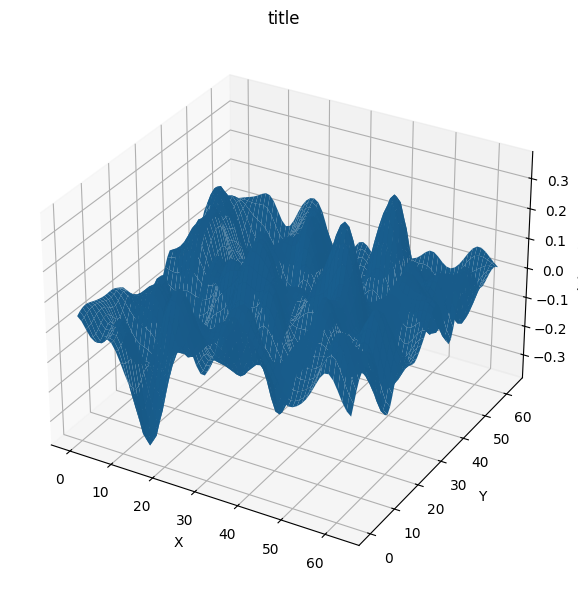

In [3]:
pl.plot_3d(hf.simulate_null_data(sigma = 2.5)[0])

Run the simulations and check the FWER error rate with no permutation correction applied

No labels (just 1 regressor in beta):

In [4]:
fwer_false_pos_rate = hf.estimate_fwer(
    n_runs=n_runs,
    n_subj=n_subj,
    img_side=img_side_length,
    sigma=smoothing_sigma,
    alpha=alpha,
    labels=False
)

print(fwer_false_pos_rate)

1.0


With A/B labels (2 regressors in beta):

In [5]:
fwer_false_pos_rate = hf.estimate_fwer(
    n_runs=n_runs,
    n_subj=n_subj,
    img_side=img_side_length,
    sigma=smoothing_sigma,
    alpha=alpha,
    labels=True
)

print(fwer_false_pos_rate)

1.0


In both cases, FWER is 1, which is very high, as expected.

# Permutation correction

With 2 labels:

In [6]:
fwer_false_pos_rate = hf.estimate_fwer(
    n_runs=n_runs,
    n_subj=n_subj,
    img_side=img_side_length,
    sigma=smoothing_sigma,
    alpha=alpha,
    labels=True,
	n_perm=n_perm
)

print(fwer_false_pos_rate)

0.0


With 1 label:

In [7]:
fwer_false_pos_rate = hf.estimate_fwer(
    n_runs=n_runs,
    n_subj=n_subj,
    img_side=img_side_length,
    sigma=smoothing_sigma,
    alpha=alpha,
    labels=False,
	n_perm=n_perm
)

print(fwer_false_pos_rate)

0.05


In [8]:
# 1. Define Ranges
test_snrs = [0]
test_sigmas = [0, 0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.1, 2.25, 2.4, 2.5, 2.6, 2.75, 2.9, 3.0] 

# 2. Run Sweep
# NOTE: n_runs=20 and n_perm=50 is LOW  quality but fast (for testing)
sens_mat0, fwer_mat0 = hf.run_2d_sweep(
    n_runs=20,          
    n_subj=n_subj,
    img_side=img_side_length,
    snr_levels=test_snrs,
    sigma_levels=test_sigmas,
    alpha=0.05,
    signal_radius=0,
    n_perm=50        
)

Starting 3D Sweep: 18 Sigmas x 1 SNRs
  > Processing Sigma = 0...
  > Processing Sigma = 0.1...
  > Processing Sigma = 0.25...
  > Processing Sigma = 0.5...
  > Processing Sigma = 0.75...
  > Processing Sigma = 1.0...
  > Processing Sigma = 1.25...
  > Processing Sigma = 1.5...
  > Processing Sigma = 1.75...
  > Processing Sigma = 2.0...
  > Processing Sigma = 2.1...
  > Processing Sigma = 2.25...
  > Processing Sigma = 2.4...
  > Processing Sigma = 2.5...
  > Processing Sigma = 2.6...
  > Processing Sigma = 2.75...
  > Processing Sigma = 2.9...
  > Processing Sigma = 3.0...
Sweep Complete.


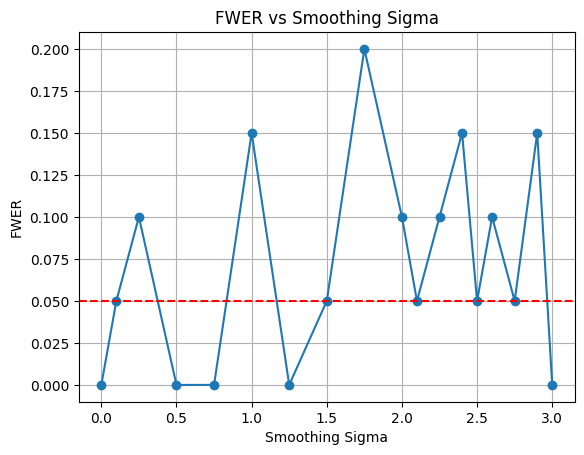

In [9]:
import numpy as np
import matplotlib.pyplot as plt
# flatten fwer array
fwer = fwer_mat0.flatten()

# plot
plt.figure()
plt.plot(test_sigmas, fwer, marker='o')
plt.xlabel("Smoothing Sigma")
plt.ylabel("FWER")
plt.title("FWER vs Smoothing Sigma")
plt.grid(True)
plt.axhline(y=0.05, linestyle='--',color='r', label='Alpha = 0.05')
plt.show()

Results typically vary from 0.04 to 0.07, which is very reasonable. This is very close to the alpha = 0.05, and is a significant improvement over the non-controlled method.


# Performance Analysis: SNR, Smoothing, and "Net Utility"

In this section we are moving beyond just checking if the method is "safe" (controlling false positives). Now we want to know if it's actually **useful**. Can it find a signal if there is one?

We are running a **2-Parameter Sweep** changing two things at once: **Signal-to-Noise Ratio (SNR)** and **Smoothing ($\sigma$)**.

### 1. The Setup (Making it Realistic)
To test this properly, we have to simulate a "Ground Truth" scenario. Here is the protocol:
1.  **Signal First, Then Smooth:** We stick a fake circular signal (Radius = 6 voxels) into the noise **before** we apply the Gaussian smoothing. This is crucial because in real fMRI, the brain activates *before* the scanner blurs the image (PSF). If we did it the other way around, it wouldn't be physically accurate.
2.  **The Sweep:** We iterate through a bunch of combinations:
    *   **SNR (0.0 - 3.0):** From "pure noise" to "obvious signal" to see when the code catches it.
    *   **Smoothing ($\sigma$ 0.5 - 3.0):** To see how much blurring messes up our ability to spot the signal vs. noise.

### 2. The "Buffer Zone" Fix
We ran into an issue where the smoothing caused the signal to "bleed" out. The signal is technically radius 6, but after smoothing, it looks like radius 8 or 9. The code was flagging those blurry edges as False Positives, which isn't really fair.

So, we implemented a **Buffer Zone**:
*   **True Mask (Radius 6):** Used to check Sensitivity (Did we find the core?).
*   **Safe Zone (Radius 6 to 10):** We ignore this ring. It's just the blurry edge.
*   **Noise Mask (Radius > 10):** The background. If we find anything here, it's definitely a False Positive (FWER).

### 3. What We Are Tracking
We are generating 3D Surface plots for these three metrics:

*   **Sensitivity (The Blue Line):** What % of the true circle did we find? (Higher is better).
*   **FWER (The Red Line):** Did we hallucinate any activation in the background? (Lower is better).
*   **Net Performance (Sensitivity minus FWER):** This is basically our "Utility Score."
    *   *Green (1.0):* Perfect. We found the signal and nothing else.
    *   *Yellow (0.0):* We found the signal, but we also found just as much noise, so it cancels out.
    *   *Red (< 0.0):* The method is useless; it's mostly detecting noise.

Here is an example of a simulated data with fake signal inserted:

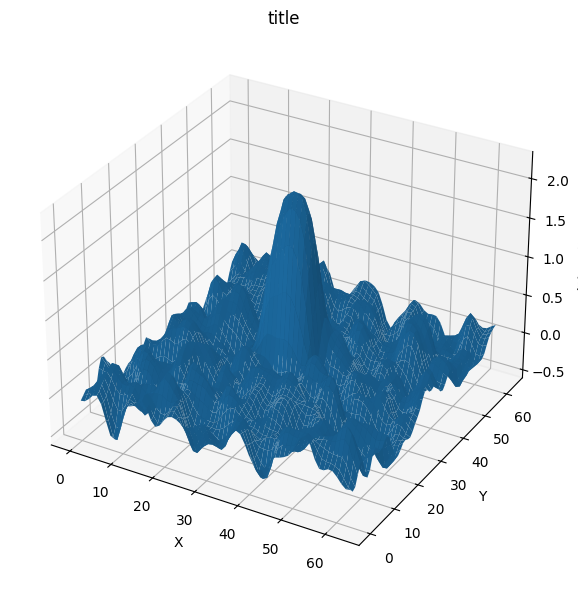

In [10]:
pl.plot_3d(hf.simulate_null_data(snr = 2, signal_radius=6, sigma = 1.5)[0])

In [11]:
test_snrs = [0, 0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.1, 2.25, 2.4, 2.5, 2.6, 2.75, 2.9, 3.0]
test_sigmas = [0, 0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.1, 2.25, 2.4, 2.5, 2.6, 2.75, 2.9, 3.0] # Low smooth -> High smooth

# 2. Run Sweep
# n_runs=20 and n_perm=50 is LOW quality but fast
# High quality: n_runs=50, n_perm=100
sens_mat, fwer_mat = hf.run_2d_sweep(
    n_runs=20,          
    n_subj=n_subj,
    img_side=img_side_length,
    snr_levels=test_snrs,
    sigma_levels=test_sigmas,
    alpha=0.05,
    signal_radius=6,
    buffer_width=4, # Set to 0 to get the "no-buffer" effect
    n_perm=50           
)

Starting 3D Sweep: 18 Sigmas x 18 SNRs
  > Processing Sigma = 0...
  > Processing Sigma = 0.1...
  > Processing Sigma = 0.25...
  > Processing Sigma = 0.5...
  > Processing Sigma = 0.75...
  > Processing Sigma = 1.0...
  > Processing Sigma = 1.25...
  > Processing Sigma = 1.5...
  > Processing Sigma = 1.75...
  > Processing Sigma = 2.0...
  > Processing Sigma = 2.1...
  > Processing Sigma = 2.25...
  > Processing Sigma = 2.4...
  > Processing Sigma = 2.5...
  > Processing Sigma = 2.6...
  > Processing Sigma = 2.75...
  > Processing Sigma = 2.9...
  > Processing Sigma = 3.0...
Sweep Complete.


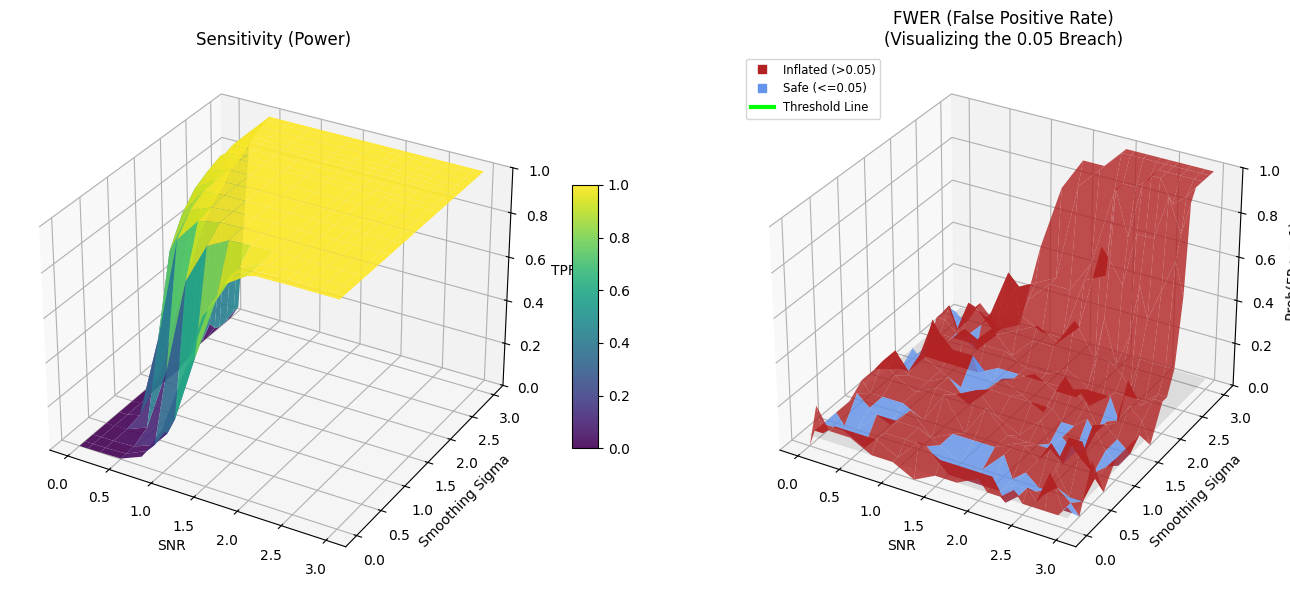

In [12]:
import importlib
import plotters as pl
importlib.reload(pl)
pl.plot_3d_surfaces(test_snrs, test_sigmas, sens_mat, fwer_mat)

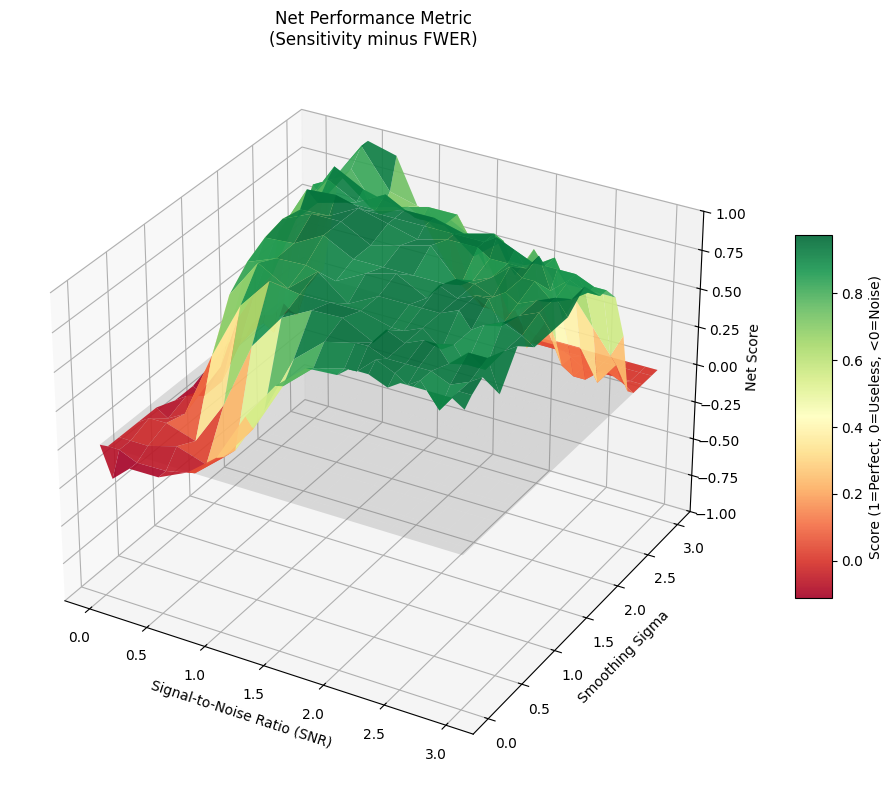

In [13]:
# Assumes you still have sens_mat, fwer_mat, test_snrs, and test_sigmas from the previous step
pl.plot_net_performance_3d(test_snrs, test_sigmas, sens_mat, fwer_mat)


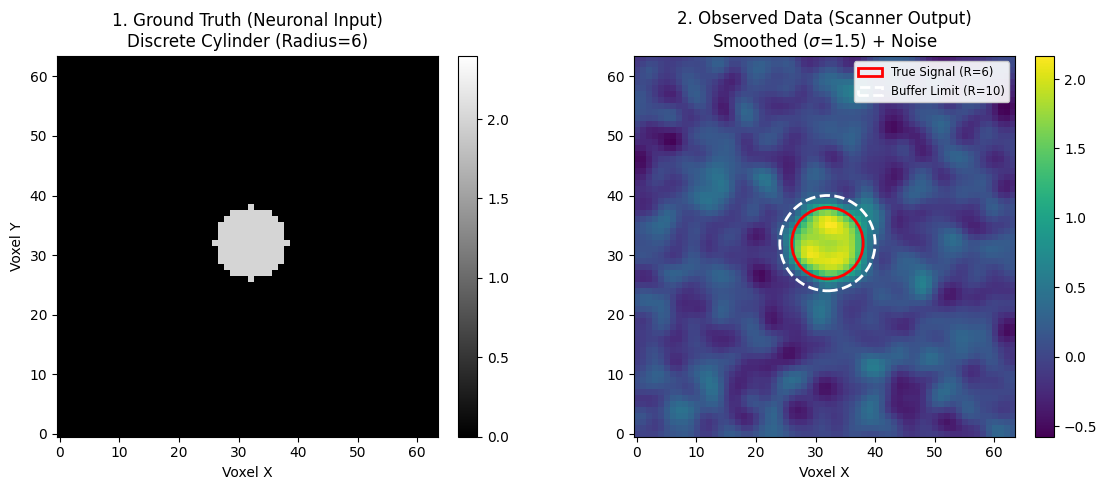

In [14]:
importlib.reload(pl)
pl.generate_method_viz()